# Credit Risk Prediction — German Credit Dataset

## Done By: 
 Nithin K S <br> Final Year Student <br>B.Tech in Computer Science and Engineering (AI & ML) <br> PES University (RR Campus), Bengaluru
 
**Objective:** Build and evaluate machine learning models to predict whether a loan applicant is a good or bad credit risk.

---
**Sections:**
1. Environment Setup & Imports
2. Data Loading
3. Data Preprocessing
4. Exploratory Data Analysis (EDA)
5. Feature Engineering
6. Model Building
7. Model Evaluation
8. Summary & Insights

---
## 1. Environment Setup & Imports

In [2]:
# ── Core Libraries ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ── Visualization ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')

# ── Preprocessing ────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.pipeline import Pipeline

# ── Models ───────────────────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# ── Evaluation ───────────────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)

print(" All libraries imported successfully.")

 All libraries imported successfully.


---
## 2. Data Loading

The **German Credit Dataset** (Statlog) contains **1000 samples** with **20 features** and a binary target:
- `1` = Good credit risk
- `2` = Bad credit risk

We load it directly from the UCI ML Repository.

In [3]:
# ── Load from UCI via ucimlrepo (recommended) ────────────────────────────────
try:
    from ucimlrepo import fetch_ucirepo
    statlog = fetch_ucirepo(id=144)          # Statlog German Credit Data
    X_raw = statlog.data.features.copy()
    y_raw = statlog.data.targets.copy()
    # Proper column names
    X_raw.columns = [
        'checking_status',
        'duration',
        'credit_history',
        'purpose',
        'credit_amount',
        'savings_status',
        'employment',
        'installment_commitment',
        'personal_status',
        'other_parties',
        'residence_since',
        'property_magnitude',
        'age',
        'other_payment_plans',
        'housing',
        'existing_credits',
        'job',
        'num_dependents',
        'own_telephone',
        'foreign_worker'
    ]

# Rename target column
    y_raw.columns = ['class']
    df = pd.concat([X_raw, y_raw], axis=1)
    print(" Dataset loaded via ucimlrepo.")

except Exception:
    # Fallback: load from URL
    print("ucimlrepo not available — loading from URL...")
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"
    col_names = [
        'checking_status','duration','credit_history','purpose','credit_amount',
        'savings_status','employment','installment_commitment','personal_status',
        'other_parties','residence_since','property_magnitude','age',
        'other_payment_plans','housing','existing_credits','job',
        'num_dependents','own_telephone','foreign_worker','class'
    ]
    df = pd.read_csv(url, sep=' ', header=None, names=col_names)
    print(" Dataset loaded from UCI URL.")

# Standardise target column name
df.columns = [c.strip() for c in df.columns]
target_col = 'class'
print(f"\nShape: {df.shape}")
df.head()

 Dataset loaded via ucimlrepo.

Shape: (1000, 21)


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


In [4]:
print("Dataset Info:")
print("=" * 50)
df.info()
print("\nTarget distribution:")
print(df[target_col].value_counts())
print("\nBasic Statistics:")
df.describe()

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   checking_status         1000 non-null   str  
 1   duration                1000 non-null   int64
 2   credit_history          1000 non-null   str  
 3   purpose                 1000 non-null   str  
 4   credit_amount           1000 non-null   int64
 5   savings_status          1000 non-null   str  
 6   employment              1000 non-null   str  
 7   installment_commitment  1000 non-null   int64
 8   personal_status         1000 non-null   str  
 9   other_parties           1000 non-null   str  
 10  residence_since         1000 non-null   int64
 11  property_magnitude      1000 non-null   str  
 12  age                     1000 non-null   int64
 13  other_payment_plans     1000 non-null   str  
 14  housing                 1000 non-null   str  
 15  existing_credits   

,duration,credit_amount,installment_commitment,residence_since,age,existing_credits,num_dependents,class
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000,1.300000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086,0.458487
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000,2.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000,2.000000


---
## 3. Data Preprocessing
### 3.1 Inspect & Handle Missing Values

In [5]:
# ── Missing value audit ───────────────────────────────────────────────────────
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_report = missing_report[missing_report['Missing Count'] > 0]

if missing_report.empty:
    print(" No missing values found in the dataset.")
else:
    print("Columns with missing values:")
    print(missing_report)
    # Strategy: fill numerical with median, categorical with mode
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = df.select_dtypes(include=['object']).columns.tolist()
    for col in missing_report.index:
        if col in num_cols:
            df[col].fillna(df[col].median(), inplace=True)
            print(f"  Filled '{col}' (numerical) with median.")
        else:
            df[col].fillna(df[col].mode()[0], inplace=True)
            print(f"  Filled '{col}' (categorical) with mode.")
    print("\n Missing values handled.")

 No missing values found in the dataset.


### 3.2 Identify Feature Types

In [6]:
# Separate features and target
X = df.drop(columns=[target_col])
y = df[target_col].copy()

# Map target: 1 → 0 (Good), 2 → 1 (Bad)
y = y.map({1: 0, 2: 1})
print("Target mapping: 1 (Good) → 0  |  2 (Bad) → 1")
print(y.value_counts().rename({0:'Good (0)', 1:'Bad (1)'}))

# Identify column types
numerical_cols   = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

print(f"\nNumerical features  ({len(numerical_cols)}): {numerical_cols}")
print(f"Categorical features ({len(categorical_cols)}): {categorical_cols}")

Target mapping: 1 (Good) → 0  |  2 (Bad) → 1
class
Good (0)    700
Bad (1)     300
Name: count, dtype: int64

Numerical features  (7): ['duration', 'credit_amount', 'installment_commitment', 'residence_since', 'age', 'existing_credits', 'num_dependents']
Categorical features (13): ['checking_status', 'credit_history', 'purpose', 'savings_status', 'employment', 'personal_status', 'other_parties', 'property_magnitude', 'other_payment_plans', 'housing', 'job', 'own_telephone', 'foreign_worker']


### 3.3 Encode Categorical Variables

In [7]:
# Label Encoding for categorical columns
label_encoders = {}
X_encoded = X.copy()

for col in categorical_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))
    label_encoders[col] = le

print(" Categorical columns label-encoded.")
print(f"\nEncoded dataset shape: {X_encoded.shape}")
X_encoded.head()

 Categorical columns label-encoded.

Encoded dataset shape: (1000, 20)


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,residence_since,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker
0,0,6,4,4,1169,4,4,4,2,0,4,0,67,2,1,2,2,1,1,0
1,1,48,2,4,5951,0,2,2,1,0,2,0,22,2,1,1,2,1,0,0
2,3,12,4,7,2096,0,3,2,2,0,3,0,49,2,1,1,1,2,0,0
3,0,42,2,3,7882,0,3,2,2,2,4,1,45,2,2,1,2,2,0,0
4,0,24,3,0,4870,0,2,3,2,0,4,3,53,2,2,2,2,2,0,0


### 3.4 Normalize / Scale Numerical Features

In [8]:
# Train-Test Split first (to avoid data leakage before scaling)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

# StandardScaler on all features
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns
)

print(f"Train set: {X_train_scaled.shape}  |  Test set: {X_test_scaled.shape}")
print(f"\nClass balance in train set:\n{y_train.value_counts()}")
print(f"\nClass balance in test  set:\n{y_test.value_counts()}")
print("\n Scaling complete.")

Train set: (800, 20)  |  Test set: (200, 20)

Class balance in train set:
class
0    560
1    240
Name: count, dtype: int64

Class balance in test  set:
class
0    140
1     60
Name: count, dtype: int64

 Scaling complete.


---
## 4. Exploratory Data Analysis (EDA)
### 4.1 Target Class Distribution

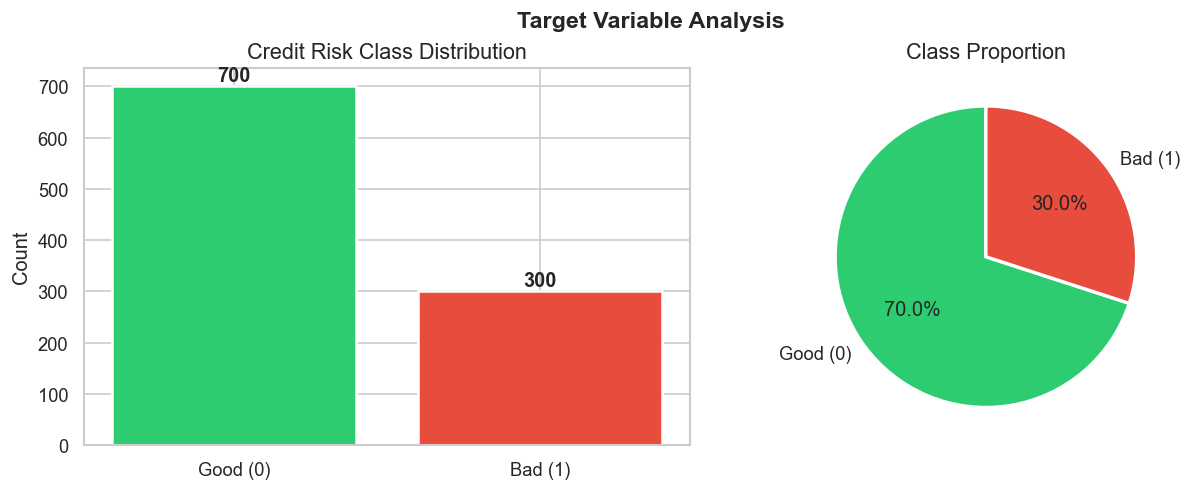

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Count plot
counts = y.value_counts().rename({0:'Good (0)', 1:'Bad (1)'})
bars = axes[0].bar(counts.index, counts.values,
                   color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=1.5)
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 10,
                 f'{int(bar.get_height())}',
                 ha='center', fontsize=12, fontweight='bold')
axes[0].set_title('Credit Risk Class Distribution', fontsize=13)
axes[0].set_ylabel('Count')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Good (0)', 'Bad (1)'])

# Pie chart
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Class Proportion', fontsize=13)

plt.tight_layout()
plt.suptitle('Target Variable Analysis', y=1.02, fontsize=14, fontweight='bold')
plt.show()

### 4.2 Numerical Feature Distributions

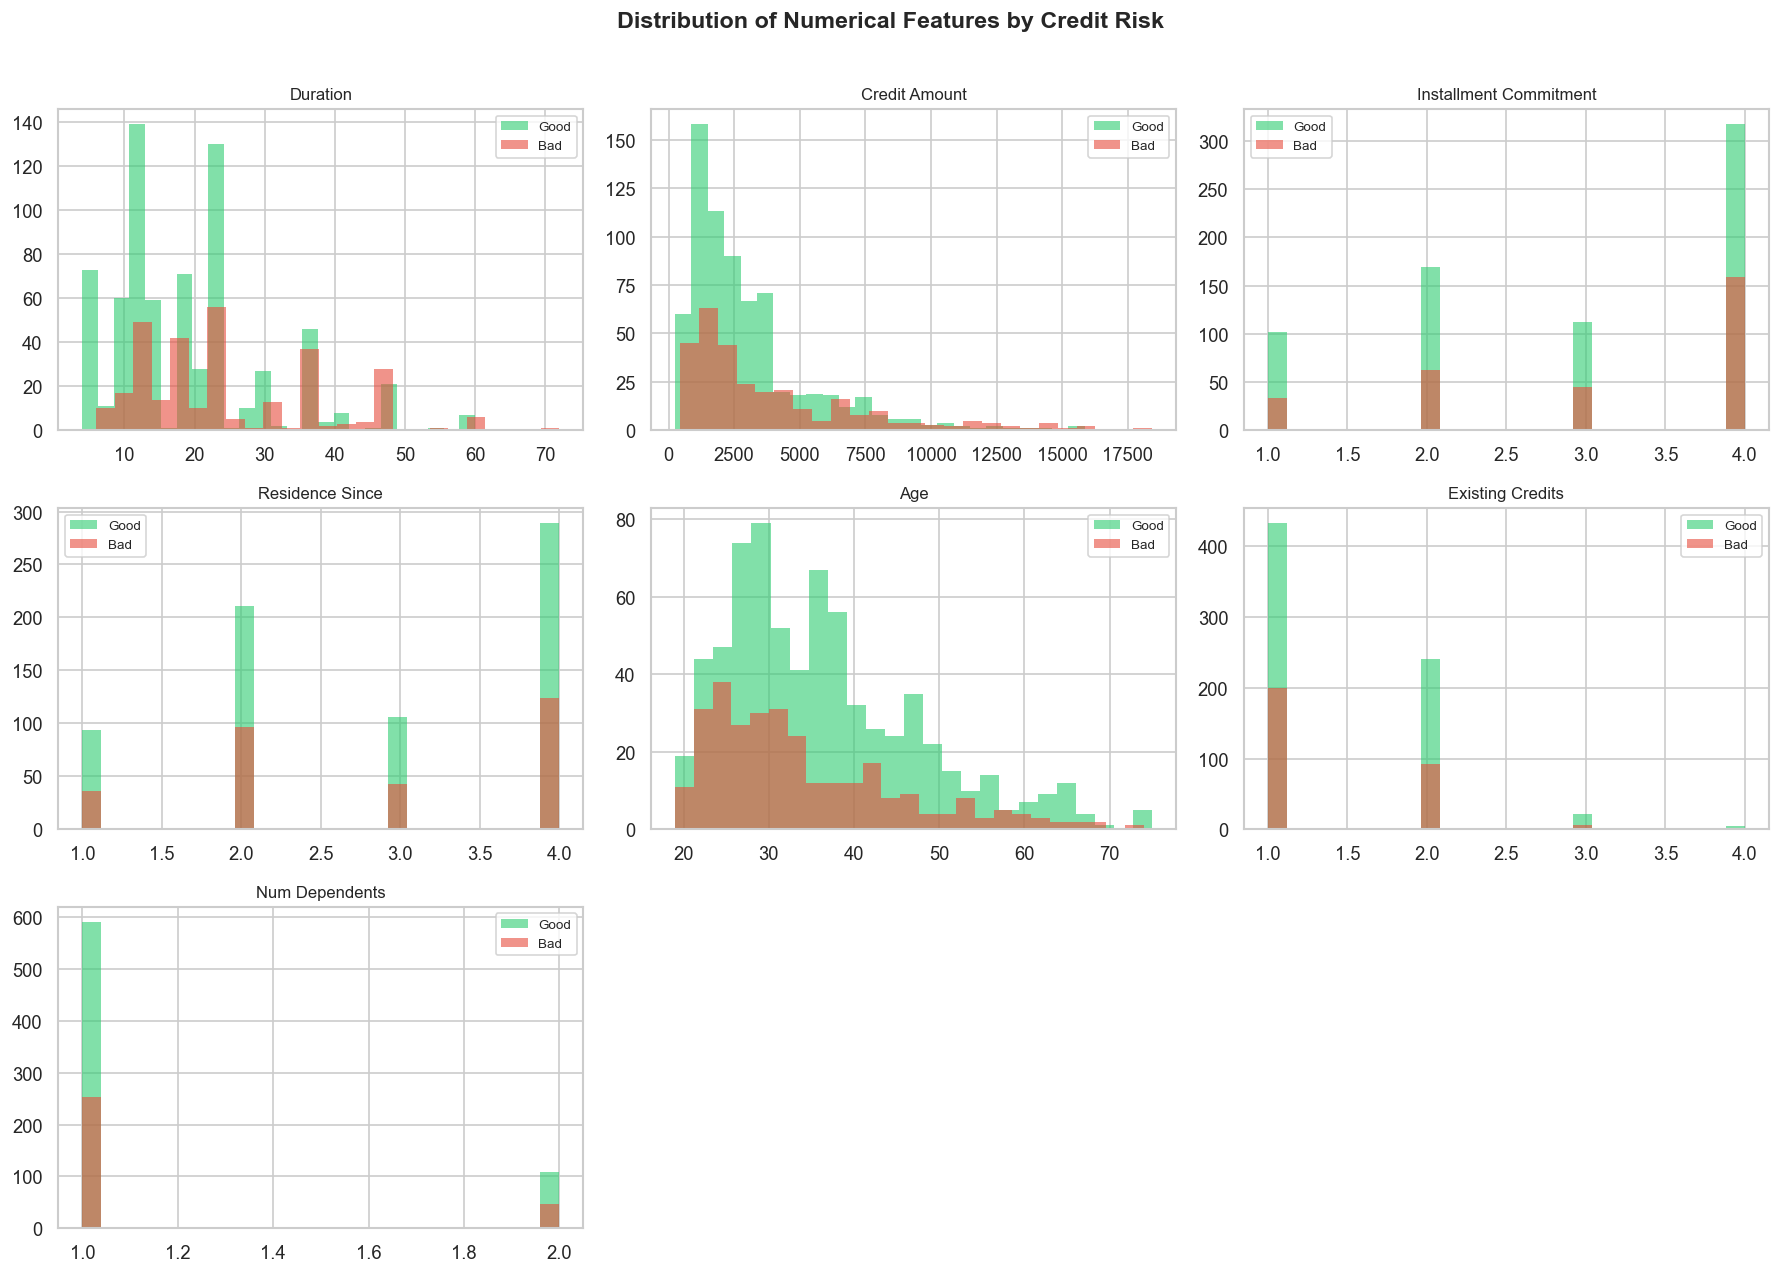

In [10]:
df_eda = X_encoded.copy()
df_eda['target'] = y.values

n = len(numerical_cols)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 3.5))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    for label, color in zip([0, 1], ['#2ecc71', '#e74c3c']):
        axes[i].hist(
            df_eda[df_eda['target'] == label][col],
            bins=25, alpha=0.6, color=color,
            label='Good' if label == 0 else 'Bad',
            edgecolor='none'
        )
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=10)
    axes[i].legend(fontsize=8)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distribution of Numerical Features by Credit Risk', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 4.3 Outlier Detection — Boxplots

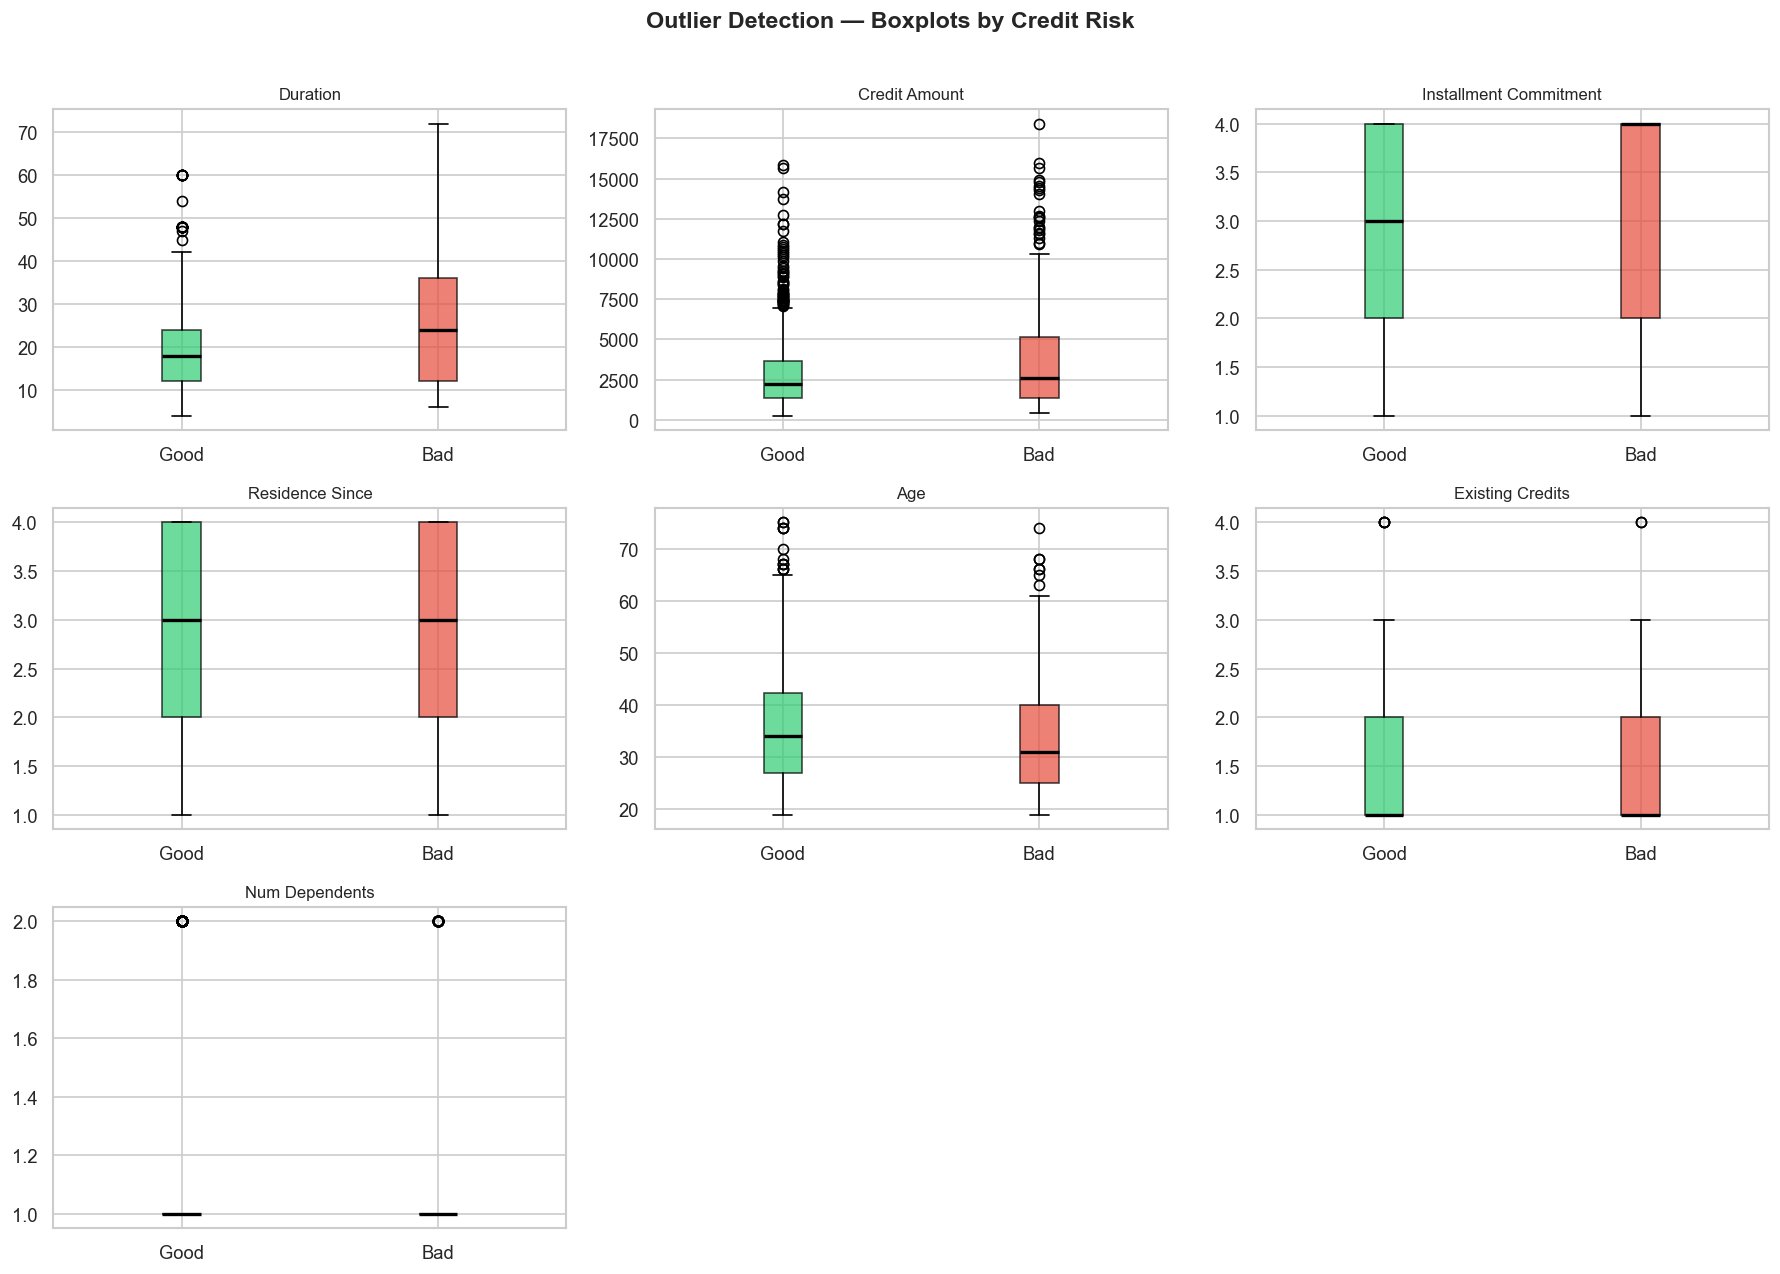

In [11]:
fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 3.5))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    data_good = df_eda[df_eda['target'] == 0][col]
    data_bad  = df_eda[df_eda['target'] == 1][col]
    bp = axes[i].boxplot(
        [data_good, data_bad],
        labels=['Good', 'Bad'],
        patch_artist=True,
        medianprops=dict(color='black', linewidth=2)
    )
    bp['boxes'][0].set_facecolor('#2ecc71')
    bp['boxes'][1].set_facecolor('#e74c3c')
    for patch in bp['boxes']:
        patch.set_alpha(0.7)
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=10)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Outlier Detection — Boxplots by Credit Risk', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 4.4 Correlation Heatmap

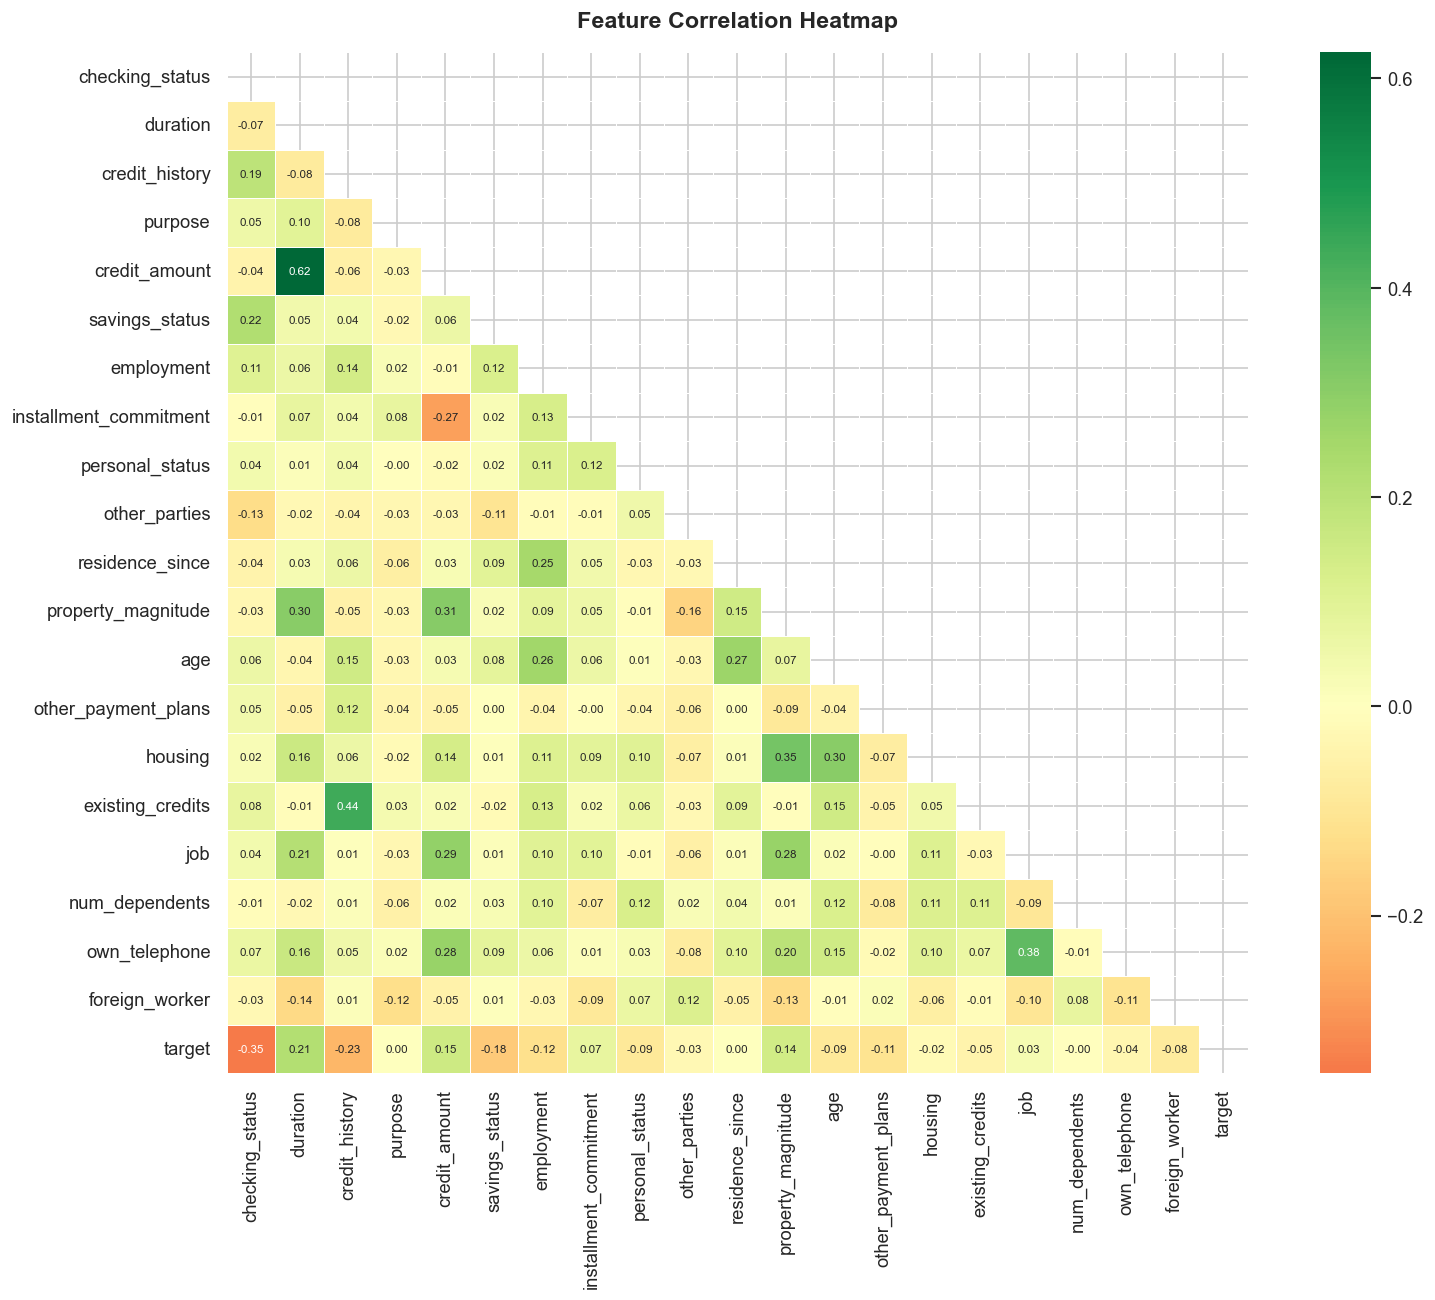

In [12]:
corr_df = df_eda.copy()
corr_matrix = corr_df.corr()

# Mask upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.5,
    ax=ax,
    annot_kws={'size': 7},
    square=True
)
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

### 4.5 Key Categorical Features vs. Target

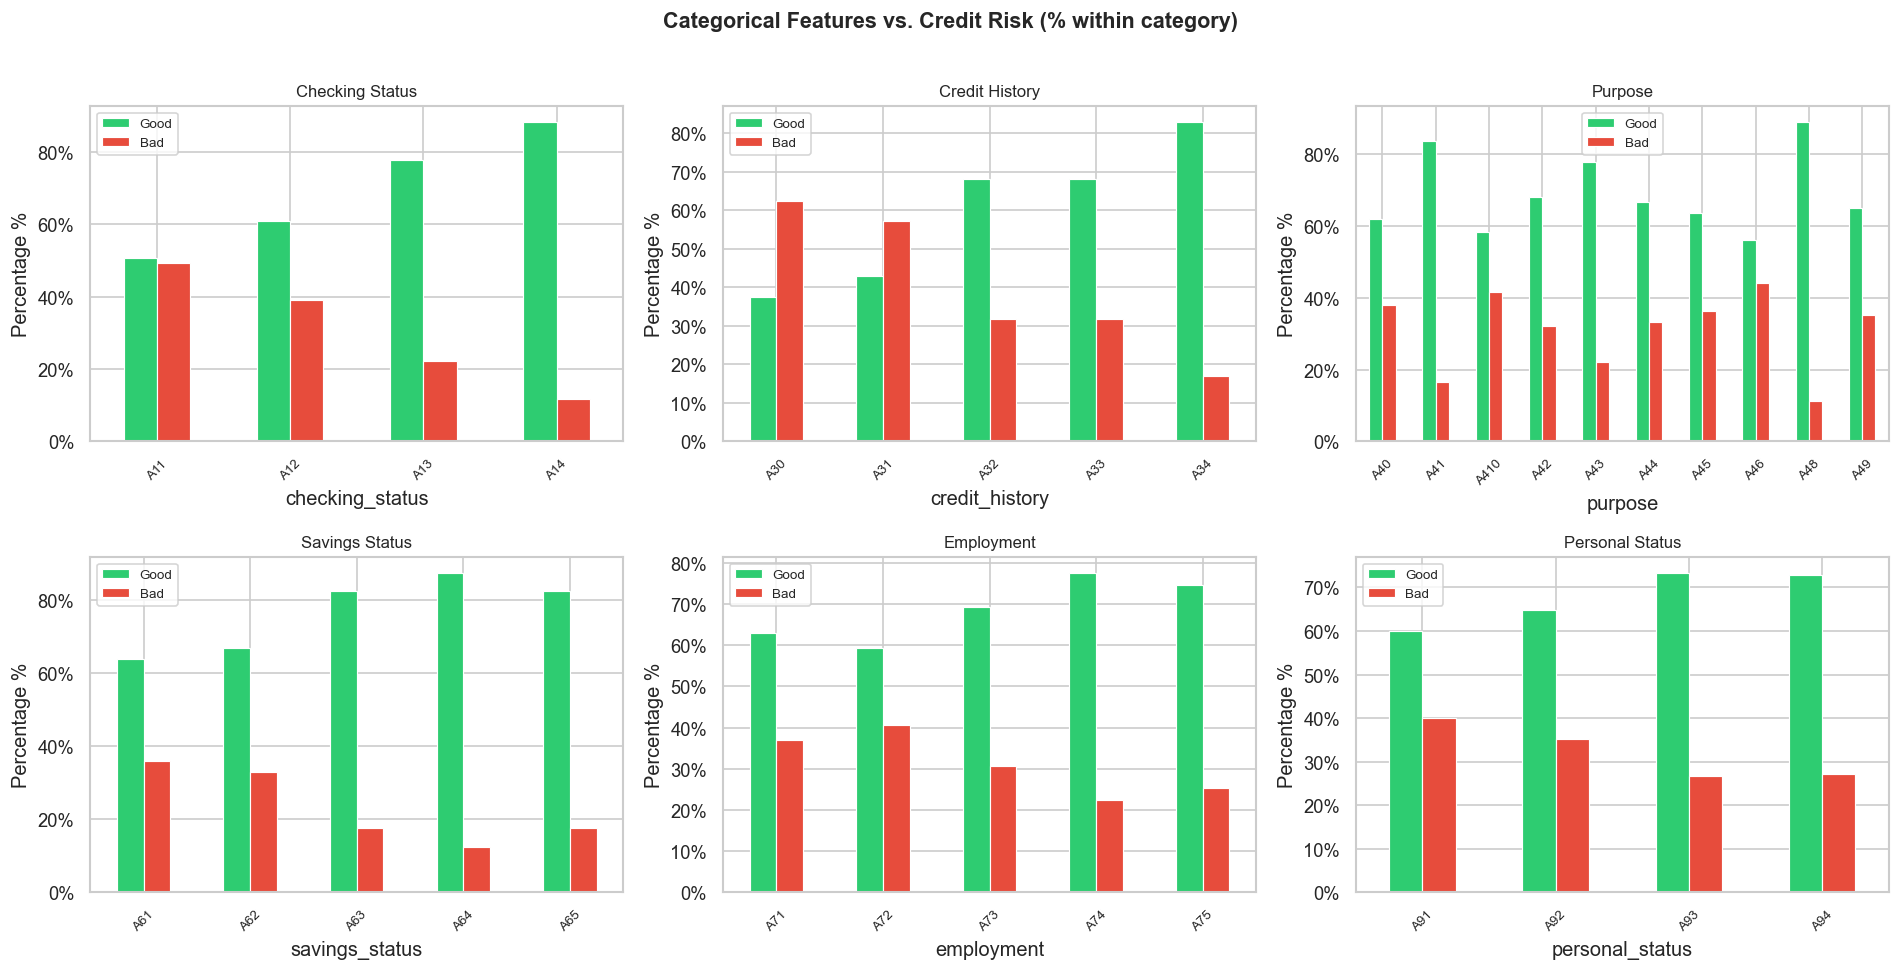

In [13]:
# Use original (non-encoded) data for readability
df_orig = X.copy()
df_orig['target'] = y.values

key_cat = categorical_cols[:6]  # top-6 categorical for display
ncols_c = 3
nrows_c = (len(key_cat) + ncols_c - 1) // ncols_c

fig, axes = plt.subplots(nrows_c, ncols_c, figsize=(16, nrows_c * 4))
axes = axes.flatten()

for i, col in enumerate(key_cat):
    ct = pd.crosstab(df_orig[col], df_orig['target'], normalize='index') * 100
    ct.columns = ['Good', 'Bad']
    ct.plot(kind='bar', ax=axes[i], color=['#2ecc71', '#e74c3c'],
            edgecolor='white', linewidth=0.7)
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=10)
    axes[i].set_ylabel('Percentage %')
    axes[i].tick_params(axis='x', rotation=45, labelsize=8)
    axes[i].legend(fontsize=8)
    axes[i].yaxis.set_major_formatter(mtick.PercentFormatter())

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Categorical Features vs. Credit Risk (% within category)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 5. Feature Engineering
### 5.1 Create Meaningful Features

In [14]:
def engineer_features(df_in):
    """Add domain-driven features to a DataFrame (expects encoded columns)."""
    df_fe = df_in.copy()

    # 1. Credit-to-Duration Ratio — higher ratio = heavier monthly burden
    if 'credit_amount' in df_fe.columns and 'duration' in df_fe.columns:
        df_fe['credit_per_month'] = df_fe['credit_amount'] / (df_fe['duration'] + 1)

    # 2. Age Group — younger applicants tend to have higher default rates
    if 'age' in df_fe.columns:
        df_fe['age_group'] = pd.cut(
            df_fe['age'],
            bins=[0, 25, 35, 50, 100],
            labels=[0, 1, 2, 3]      # 0=Young, 1=Mid, 2=Senior, 3=Retired
        ).astype(int)

    # 3. High Credit Flag — amounts above 75th percentile
    if 'credit_amount' in df_fe.columns:
        q75 = df_fe['credit_amount'].quantile(0.75)
        df_fe['high_credit'] = (df_fe['credit_amount'] > q75).astype(int)

    # 4. Long Duration Flag — duration above median (risky long-term loans)
    if 'duration' in df_fe.columns:
        med_dur = df_fe['duration'].median()
        df_fe['long_duration'] = (df_fe['duration'] > med_dur).astype(int)

    # 5. Installment Burden — installment commitment relative to duration
    if 'installment_commitment' in df_fe.columns and 'duration' in df_fe.columns:
        df_fe['installment_burden'] = df_fe['installment_commitment'] * df_fe['duration']

    return df_fe

X_fe = engineer_features(X_encoded)
print(f"Features before engineering: {X_encoded.shape[1]}")
print(f"Features after  engineering: {X_fe.shape[1]}")
print(f"\nNew features added: {set(X_fe.columns) - set(X_encoded.columns)}")

Features before engineering: 20
Features after  engineering: 25

New features added: {'credit_per_month', 'long_duration', 'high_credit', 'installment_burden', 'age_group'}


### 5.2 Remove Irrelevant / Redundant Features

In [15]:
# Check for near-zero variance features
from sklearn.feature_selection import VarianceThreshold

vt = VarianceThreshold(threshold=0.01)
vt.fit(X_fe)
removed = [col for col, kept in zip(X_fe.columns, vt.get_support()) if not kept]

if removed:
    print(f"Removing low-variance features: {removed}")
    X_fe.drop(columns=removed, inplace=True)
else:
    print(" No low-variance features found — all features retained.")

# Check for highly correlated feature pairs (|r| > 0.95)
corr_mat = X_fe.corr().abs()
upper_tri = corr_mat.where(np.triu(np.ones(corr_mat.shape), k=1).astype(bool))
to_drop_corr = [col for col in upper_tri.columns if any(upper_tri[col] > 0.95)]

if to_drop_corr:
    print(f"Dropping highly correlated features (|r|>0.95): {to_drop_corr}")
    X_fe.drop(columns=to_drop_corr, inplace=True)
else:
    print(" No highly correlated feature pairs found.")

print(f"\nFinal feature count: {X_fe.shape[1]}")

 No low-variance features found — all features retained.
 No highly correlated feature pairs found.

Final feature count: 25


### 5.3 Feature Importance Preview (Random Forest)

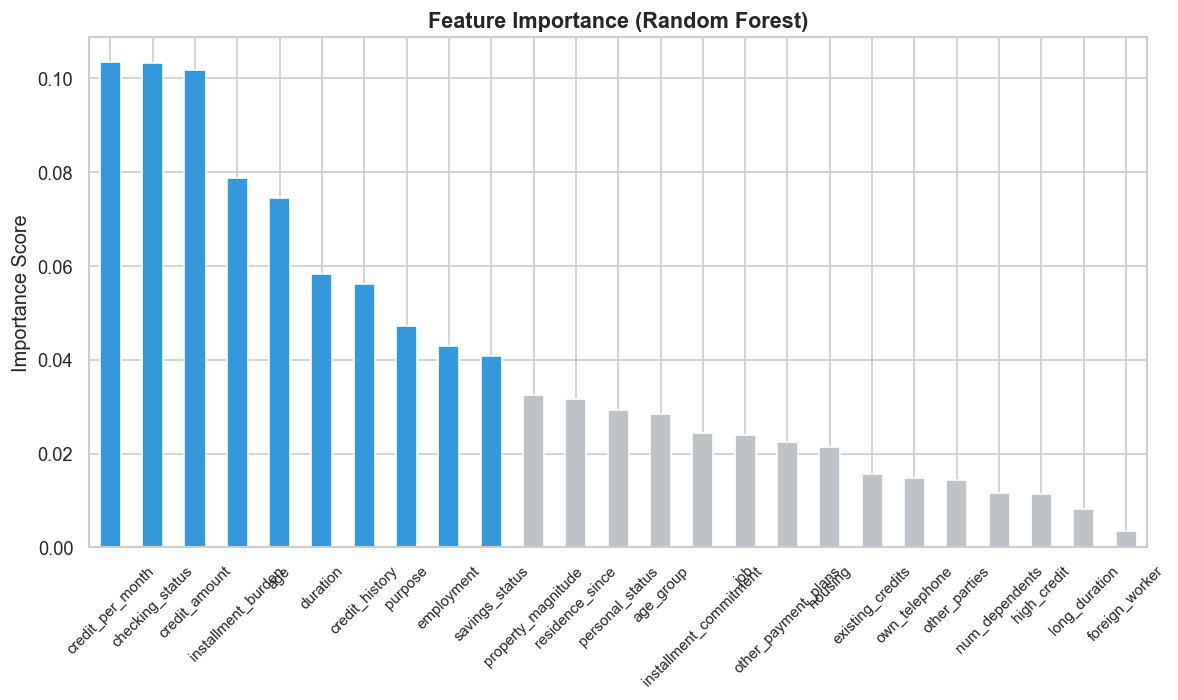

Top 15 features selected: ['credit_per_month', 'checking_status', 'credit_amount', 'installment_burden', 'age', 'duration', 'credit_history', 'purpose', 'employment', 'savings_status', 'property_magnitude', 'residence_since', 'personal_status', 'age_group', 'installment_commitment']


In [16]:
# Quick RF for importance ranking before full model training
rf_quick = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_quick.fit(X_fe, y)

importances = pd.Series(rf_quick.feature_importances_, index=X_fe.columns)
importances = importances.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#3498db' if i < 10 else '#bdc3c7' for i in range(len(importances))]
importances.plot(kind='bar', ax=ax, color=colors, edgecolor='white')
ax.set_title('Feature Importance (Random Forest)', fontsize=13, fontweight='bold')
ax.set_ylabel('Importance Score')
ax.tick_params(axis='x', rotation=45, labelsize=9)
plt.tight_layout()
plt.show()

# Keep top-15 features for model training
TOP_N = 15
top_features = importances.head(TOP_N).index.tolist()
print(f"Top {TOP_N} features selected: {top_features}")

In [17]:
# Rebuild train/test splits using engineered features
X_selected = X_fe[top_features]

X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    X_selected, y, test_size=0.2, random_state=42, stratify=y
)

scaler_fe = StandardScaler()
X_train_fe_sc = pd.DataFrame(scaler_fe.fit_transform(X_train_fe), columns=top_features)
X_test_fe_sc  = pd.DataFrame(scaler_fe.transform(X_test_fe),  columns=top_features)

print(f"Train: {X_train_fe_sc.shape}  |  Test: {X_test_fe_sc.shape}")

Train: (800, 15)  |  Test: (200, 15)


---
## 6. Model Building

We train four classifiers:
1. Logistic Regression
2. Decision Tree
3. Random Forest
4. Gradient Boosting

In [18]:
# models = {
#     'Logistic Regression': LogisticRegression(
#         max_iter=1000, random_state=42, class_weight='balanced'
#     ),
#     'Decision Tree': DecisionTreeClassifier(
#         max_depth=6, min_samples_split=20, random_state=42, class_weight='balanced'
#     ),
#     'Random Forest': RandomForestClassifier(
#         n_estimators=200, max_depth=10, min_samples_split=10,
#         random_state=42, class_weight='balanced', n_jobs=-1
#     ),
#     'Gradient Boosting': GradientBoostingClassifier(
#         n_estimators=200, learning_rate=0.05, max_depth=4,
#         subsample=0.8, random_state=42
#     )
# }

# trained_models = {}
# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# print("Training models with 5-Fold Cross Validation...\n")
# print(f"{'Model':<22} {'CV Accuracy':>12} {'CV AUC':>10}")
# print("-" * 46)

# for name, model in models.items():
#     model.fit(X_train_fe_sc, y_train_fe)
#     trained_models[name] = model

#     cv_acc = cross_val_score(model, X_train_fe_sc, y_train_fe, cv=cv, scoring='accuracy').mean()
#     cv_auc = cross_val_score(model, X_train_fe_sc, y_train_fe, cv=cv, scoring='roc_auc').mean()
#     print(f"{name:<22} {cv_acc:>12.4f} {cv_auc:>10.4f}")

# print("\n All models trained.")

In [19]:
import os
import joblib
# =========================================================
# Create models directory
# =========================================================
os.makedirs("models", exist_ok=True)

# =========================================================
# Define Models
# =========================================================
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight='balanced'
    ),

    'Decision Tree': DecisionTreeClassifier(
        max_depth=6,
        min_samples_split=20,
        random_state=42,
        class_weight='balanced'
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_split=10,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    ),

    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        random_state=42
    )
}

# =========================================================
# Cross Validation Setup
# =========================================================
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# =========================================================
# Store Results
# =========================================================
results = []
trained_models = {}

print("Training models with 5-Fold Cross Validation...\n")
print(f"{'Model':<22} {'CV Accuracy':>12} {'CV ROC-AUC':>15}")
print("-" * 52)

# =========================================================
# Train + Evaluate Models
# =========================================================
for name, model in models.items():

    # Cross Validation Scores
    cv_acc = cross_val_score(
        model,
        X_train_fe_sc,
        y_train_fe,
        cv=cv,
        scoring='accuracy'
    ).mean()

    cv_auc = cross_val_score(
        model,
        X_train_fe_sc,
        y_train_fe,
        cv=cv,
        scoring='roc_auc'
    ).mean()

    # Train Final Model
    model.fit(X_train_fe_sc, y_train_fe)

    # Store trained model
    trained_models[name] = model

    # Save model
    model_filename = f"../models/{name.lower().replace(' ', '_')}.pkl"
    joblib.dump(model, model_filename)

    # Store results
    results.append({
        'Model': name,
        'CV Accuracy': round(cv_acc, 4),
        'CV ROC-AUC': round(cv_auc, 4)
    })

    # Print Results
    print(f"{name:<22} {cv_acc:>12.4f} {cv_auc:>15.4f}")

# =========================================================
# Save Scaler
# =========================================================
joblib.dump(scaler, "../models/scaler.pkl")

# =========================================================
# Save Feature Columns
# =========================================================
joblib.dump(X_train_fe.columns.tolist(), "models/feature_columns.pkl")

# =========================================================
# Results DataFrame
# =========================================================
results_df = pd.DataFrame(results)

print("\n All models trained and saved successfully.")
print("\nSaved files inside ../models directory:")
print("- Trained Models (.pkl)")
print("- scaler.pkl")
print("- feature_columns.pkl")

# =========================================================
# Display Results
# =========================================================
results_df

Training models with 5-Fold Cross Validation...

Model                   CV Accuracy      CV ROC-AUC
----------------------------------------------------
Logistic Regression          0.7113          0.7743
Decision Tree                0.6750          0.7387
Random Forest                0.7450          0.7919
Gradient Boosting            0.7588          0.7717

 All models trained and saved successfully.

Saved files inside ../models directory:
- Trained Models (.pkl)
- scaler.pkl
- feature_columns.pkl


,Model,CV Accuracy,CV ROC-AUC
0,Logistic Regression,0.7113,0.7743
1,Decision Tree,0.6750,0.7387
2,Random Forest,0.7450,0.7919
3,Gradient Boosting,0.7588,0.7717


---
## 7. Model Evaluation
### 7.1 Metrics Table

In [20]:
# results = []

# for name, model in trained_models.items():
#     y_pred     = model.predict(X_test_fe_sc)
#     y_proba    = model.predict_proba(X_test_fe_sc)[:, 1]

#     acc  = accuracy_score(y_test_fe, y_pred)
#     prec = precision_score(y_test_fe, y_pred, zero_division=0)
#     rec  = recall_score(y_test_fe, y_pred, zero_division=0)
#     f1   = f1_score(y_test_fe, y_pred, zero_division=0)
#     auc  = roc_auc_score(y_test_fe, y_proba)

#     results.append({
#         'Model': name,
#         'Accuracy': round(acc, 4),
#         'Precision': round(prec, 4),
#         'Recall': round(rec, 4),
#         'F1 Score': round(f1, 4),
#         'ROC-AUC': round(auc, 4)
#     })

# results_df = pd.DataFrame(results).set_index('Model')
# print("Test Set Evaluation Metrics")
# print("=" * 65)
# results_df

In [21]:
# =========================================================
# Load Saved Models
# =========================================================
saved_model_files = {
    'Logistic Regression': '../models/logistic_regression.pkl',
    'Decision Tree': '../models/decision_tree.pkl',
    'Random Forest': '../models/random_forest.pkl',
    'Gradient Boosting': '../models/gradient_boosting.pkl'
}

# =========================================================
# Store Evaluation Results
# =========================================================
results = []

print("Evaluating Saved Models on Test Data...\n")

# =========================================================
# Evaluate Each Saved Model
# =========================================================
for name, model_path in saved_model_files.items():

    # Load trained model
    model = joblib.load(model_path)

    # Predictions
    y_pred = model.predict(X_test_fe_sc)
    y_proba = model.predict_proba(X_test_fe_sc)[:, 1]

    # Metrics
    acc  = accuracy_score(y_test_fe, y_pred)
    prec = precision_score(y_test_fe, y_pred, zero_division=0)
    rec  = recall_score(y_test_fe, y_pred, zero_division=0)
    f1   = f1_score(y_test_fe, y_pred, zero_division=0)
    auc  = roc_auc_score(y_test_fe, y_proba)

    # Store Results
    results.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1 Score': round(f1, 4),
        'ROC-AUC': round(auc, 4)
    })

# =========================================================
# Results DataFrame
# =========================================================
results_df = pd.DataFrame(results).set_index('Model')

print("Test Set Evaluation Metrics")
print("=" * 65)

results_df

Evaluating Saved Models on Test Data...

Test Set Evaluation Metrics


,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Model,,,,,
Logistic Regression,0.730,0.5375,0.7167,0.6143,0.7783
Decision Tree,0.655,0.4545,0.7500,0.5660,0.7079
Random Forest,0.750,0.5694,0.6833,0.6212,0.7882
Gradient Boosting,0.770,0.6591,0.4833,0.5577,0.7945


### 7.2 Metrics Bar Chart Comparison

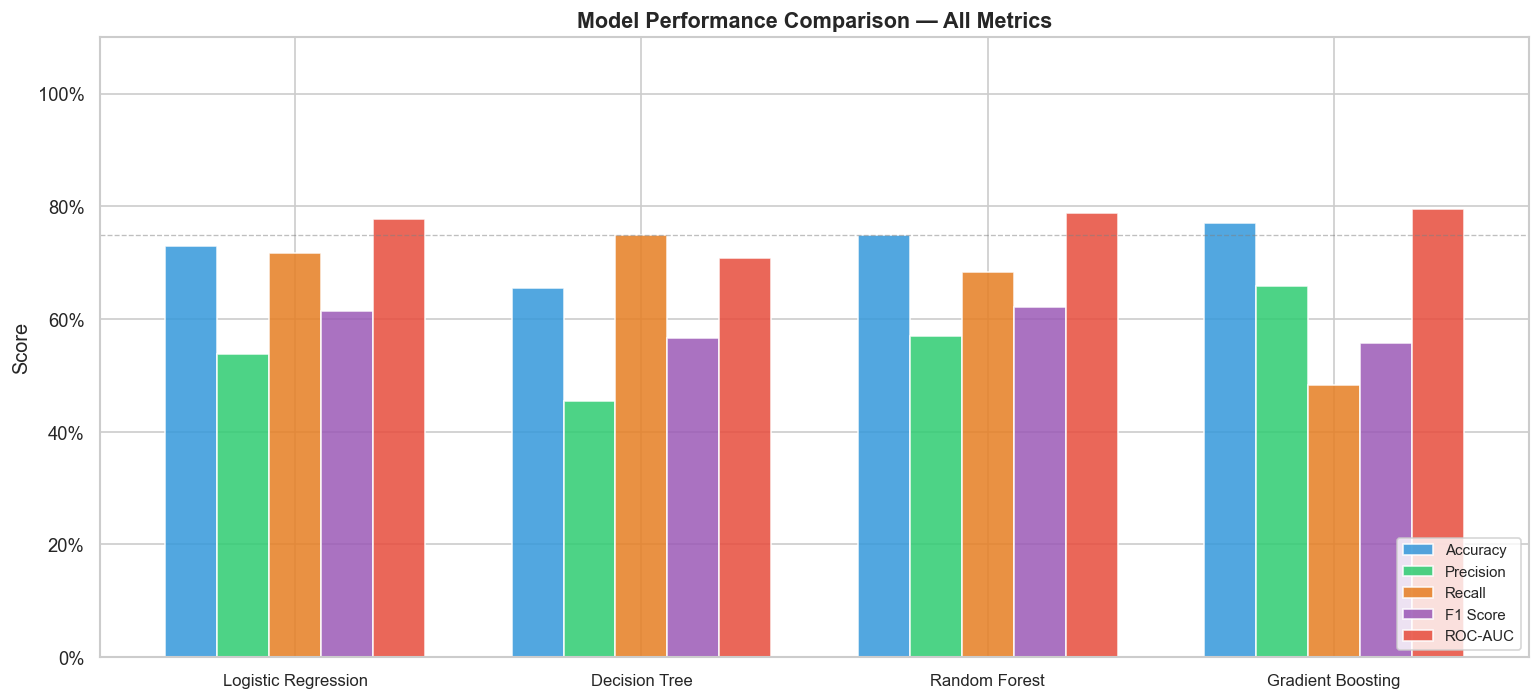

In [22]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
x = np.arange(len(results_df))
width = 0.15
colors_m = ['#3498db', '#2ecc71', '#e67e22', '#9b59b6', '#e74c3c']

fig, ax = plt.subplots(figsize=(13, 6))
for i, (metric, color) in enumerate(zip(metrics, colors_m)):
    bars = ax.bar(x + i * width, results_df[metric], width,
                  label=metric, color=color, alpha=0.85, edgecolor='white')

ax.set_xticks(x + width * 2)
ax.set_xticklabels(results_df.index, fontsize=10)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison — All Metrics', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.axhline(0.75, color='gray', linestyle='--', linewidth=0.8, alpha=0.5, label='75% line')

plt.tight_layout()
plt.show()

### 7.3 Confusion Matrices

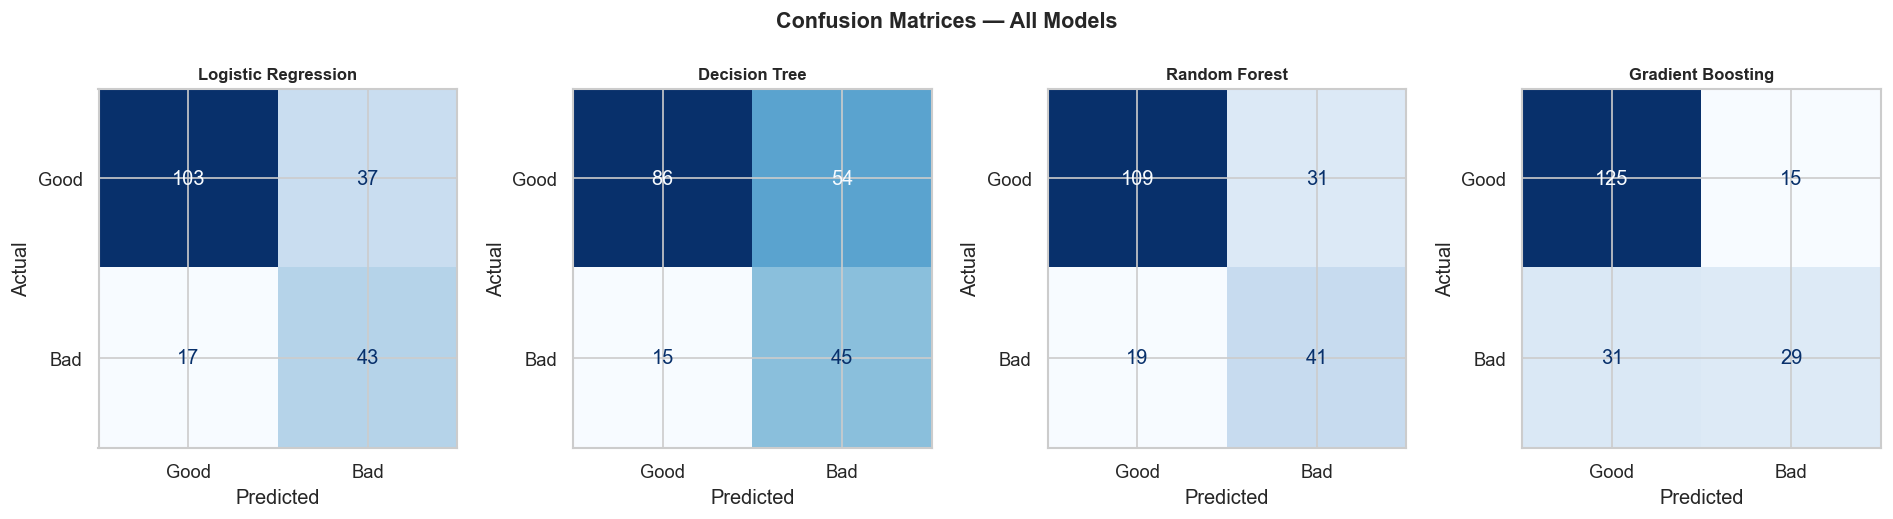

In [23]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, (name, model) in zip(axes, trained_models.items()):
    y_pred = model.predict(X_test_fe_sc)
    cm = confusion_matrix(y_test_fe, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Good', 'Bad'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=10, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

fig.suptitle('Confusion Matrices — All Models', fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

### 7.4 ROC Curves

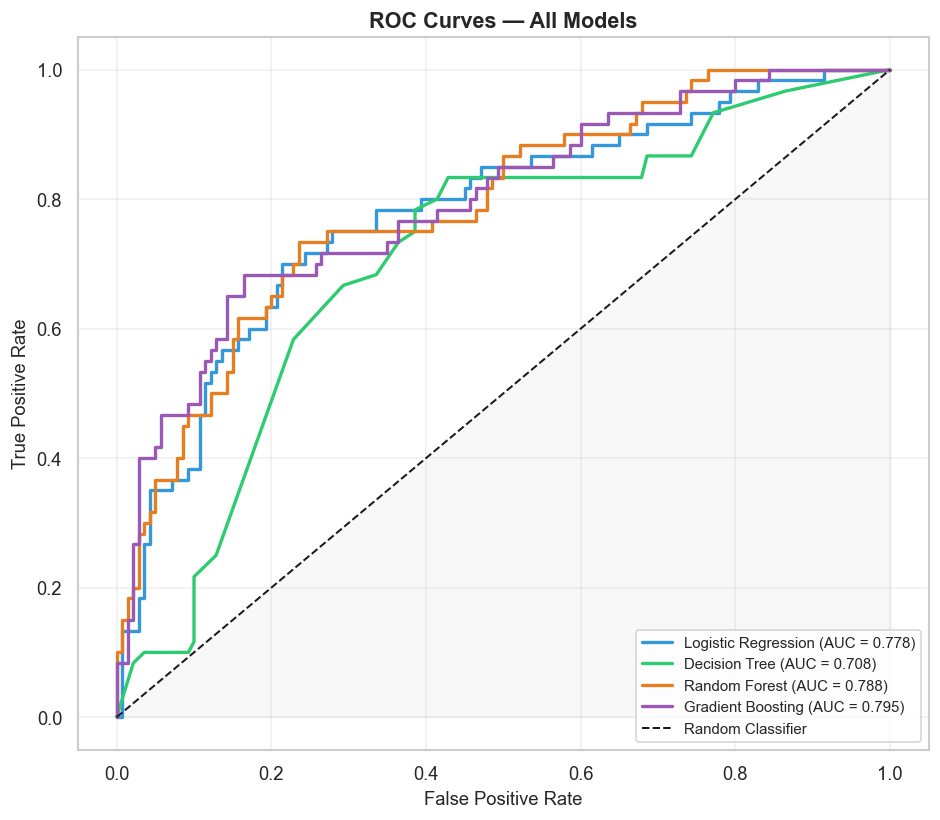

In [24]:
fig, ax = plt.subplots(figsize=(8, 7))
plot_colors = ['#3498db', '#2ecc71', '#e67e22', '#9b59b6']

for (name, model), color in zip(trained_models.items(), plot_colors):
    y_proba = model.predict_proba(X_test_fe_sc)[:, 1]
    fpr, tpr, _ = roc_curve(y_test_fe, y_proba)
    auc = roc_auc_score(y_test_fe, y_proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})", color=color, linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1.2, label='Random Classifier')
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curves — All Models', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 7.5 Classification Reports

In [25]:
for name, model in trained_models.items():
    y_pred = model.predict(X_test_fe_sc)
    print(f"{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(classification_report(y_test_fe, y_pred, target_names=['Good (0)', 'Bad (1)']))

  Logistic Regression
              precision    recall  f1-score   support

    Good (0)       0.86      0.74      0.79       140
     Bad (1)       0.54      0.72      0.61        60

    accuracy                           0.73       200
   macro avg       0.70      0.73      0.70       200
weighted avg       0.76      0.73      0.74       200

  Decision Tree
              precision    recall  f1-score   support

    Good (0)       0.85      0.61      0.71       140
     Bad (1)       0.45      0.75      0.57        60

    accuracy                           0.66       200
   macro avg       0.65      0.68      0.64       200
weighted avg       0.73      0.66      0.67       200

  Random Forest
              precision    recall  f1-score   support

    Good (0)       0.85      0.78      0.81       140
     Bad (1)       0.57      0.68      0.62        60

    accuracy                           0.75       200
   macro avg       0.71      0.73      0.72       200
weighted avg       0

### 7.6 Decision Tree Visualization

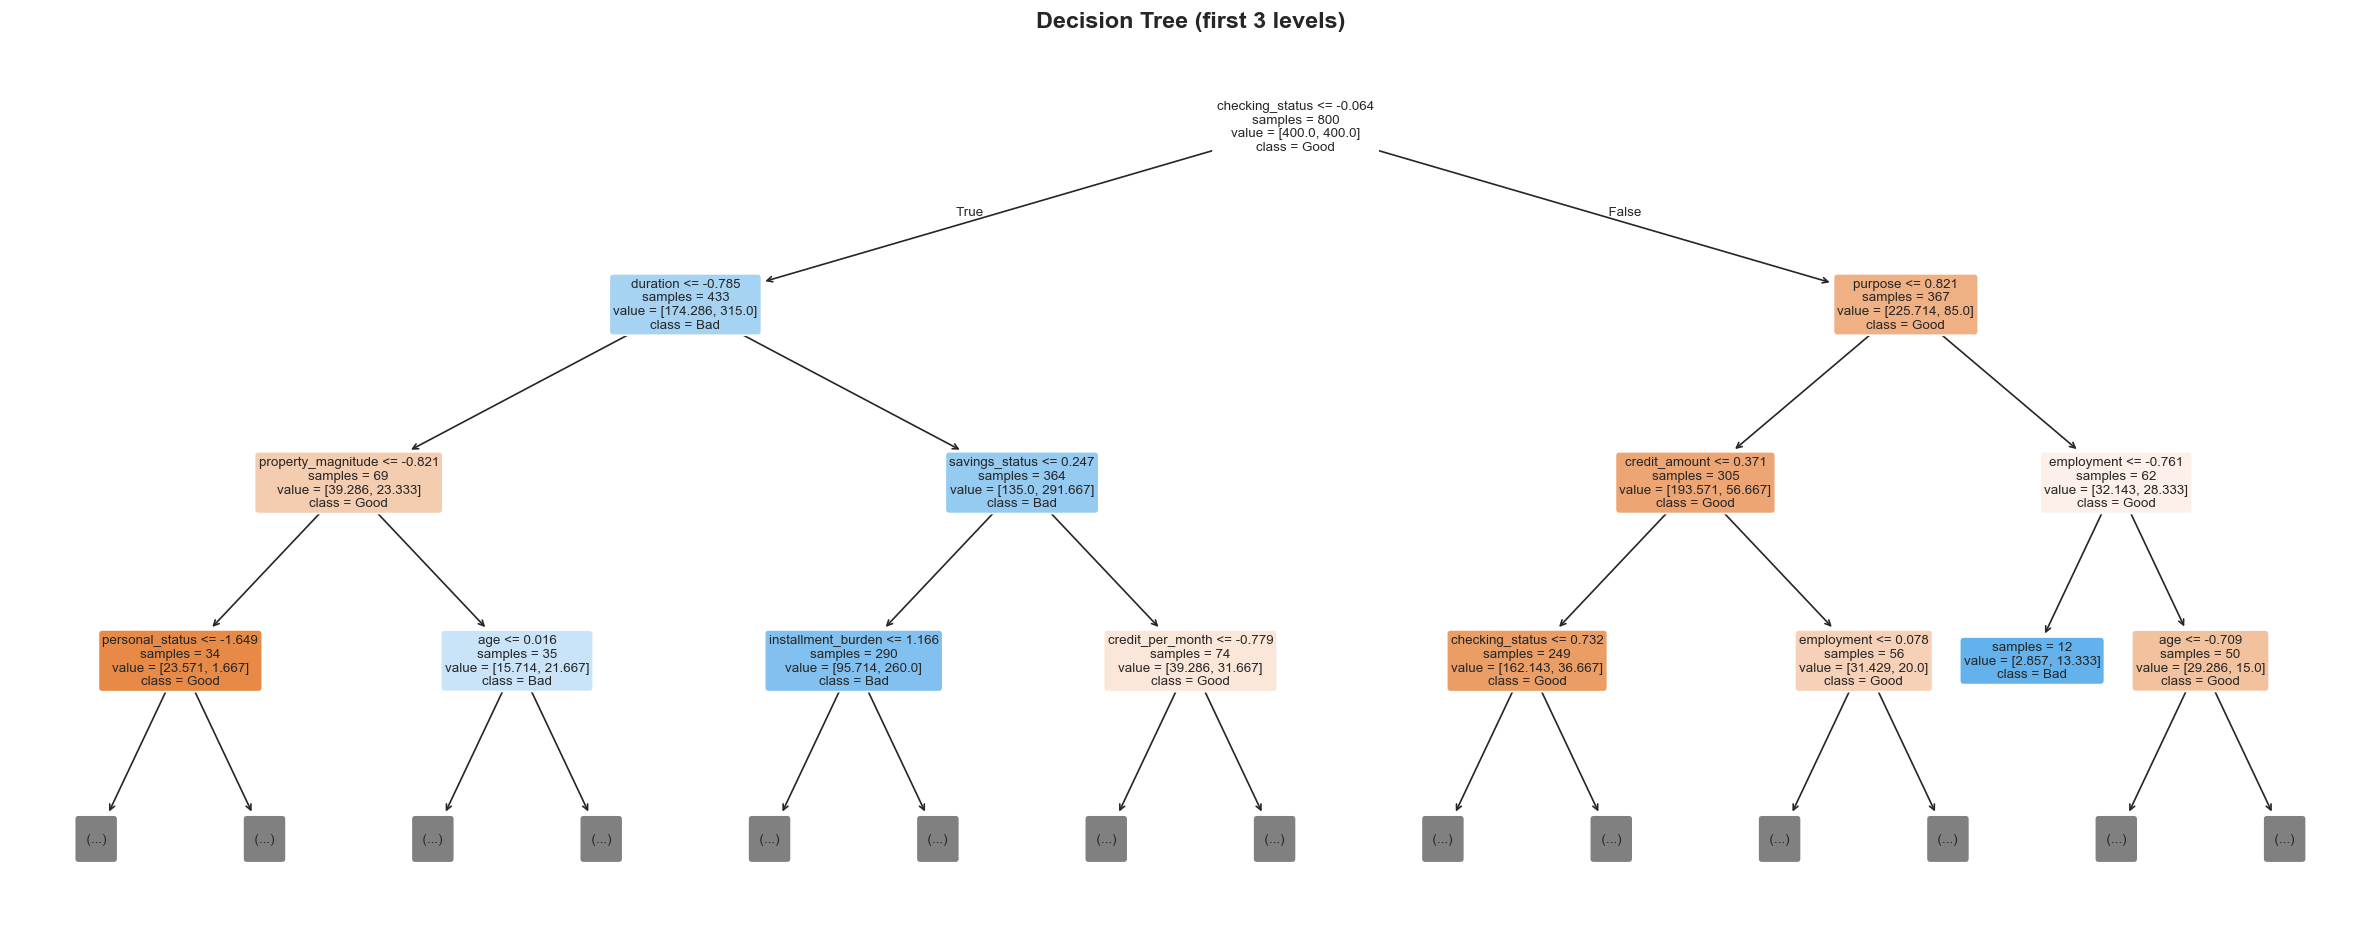

In [26]:
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    trained_models['Decision Tree'],
    feature_names=top_features,
    class_names=['Good', 'Bad'],
    filled=True,
    rounded=True,
    max_depth=3,        # show first 3 levels for clarity
    fontsize=8,
    ax=ax,
    impurity=False
)
ax.set_title('Decision Tree (first 3 levels)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 7.7 Best Model — Feature Importance

Best model (by ROC-AUC): Gradient Boosting


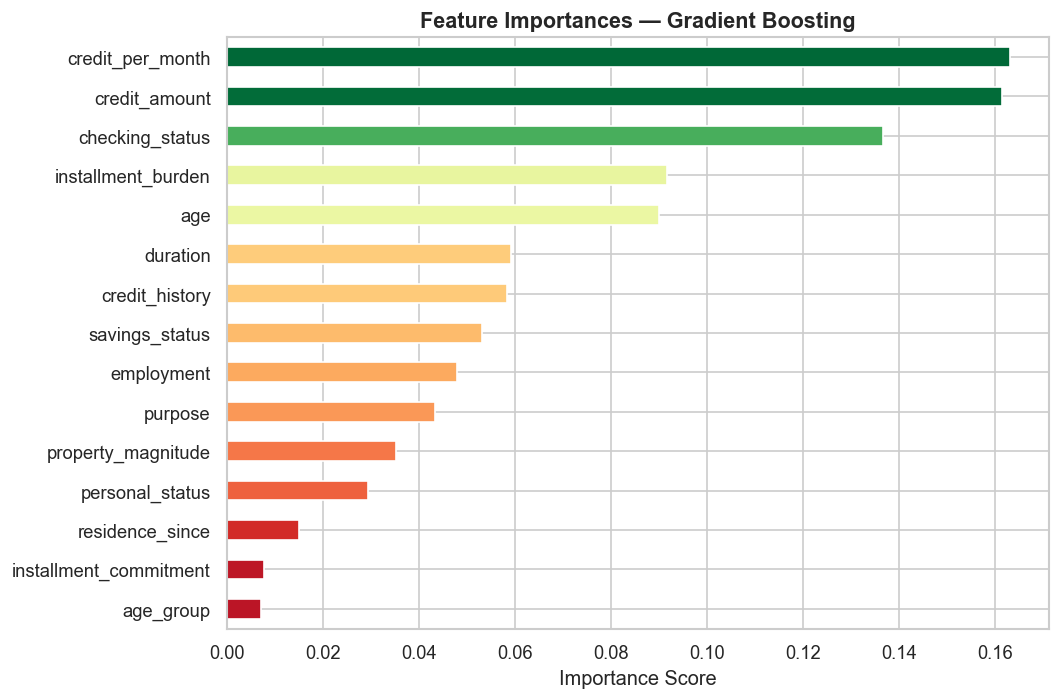

In [27]:
# Identify best model by ROC-AUC
best_model_name = results_df['ROC-AUC'].idxmax()
best_model = trained_models[best_model_name]
print(f"Best model (by ROC-AUC): {best_model_name}")

# Feature importances
if hasattr(best_model, 'feature_importances_'):
    feat_imp = pd.Series(best_model.feature_importances_, index=top_features).sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(9, 6))
    cmap = plt.cm.RdYlGn
    colors_imp = [cmap(v / feat_imp.max()) for v in feat_imp]
    feat_imp.plot(kind='barh', ax=ax, color=colors_imp, edgecolor='white')
    ax.set_title(f'Feature Importances — {best_model_name}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Importance Score')
    plt.tight_layout()
    plt.show()
elif hasattr(best_model, 'coef_'):
    coefs = pd.Series(np.abs(best_model.coef_[0]), index=top_features).sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(9, 6))
    coefs.plot(kind='barh', ax=ax, color='#3498db', edgecolor='white')
    ax.set_title(f'Feature Coefficients — {best_model_name}', fontsize=13, fontweight='bold')
    ax.set_xlabel('|Coefficient|')
    plt.tight_layout()
    plt.show()

---
## 8. Summary & Insights

In [28]:
print("\n" + "═" * 65)
print("   CREDIT RISK PREDICTION — FINAL SUMMARY")
print("═" * 65)

print("\n DATASET")
print(f"   Samples : 1000  |  Features (original): 20  |  Target: Binary")
print(f"   Good credit (0) : 700  |  Bad credit (1) : 300")

print("\n PREPROCESSING")
print("   • No missing values found in the dataset")
print("   • Label Encoding applied to all categorical features")
print("   • StandardScaler applied to all features")

print("\n FEATURE ENGINEERING")
print("   New features created:")
print("   • credit_per_month — monthly credit burden")
print("   • age_group        — binned age brackets")
print("   • high_credit      — credit above 75th percentile")
print("   • long_duration    — duration above median")
print("   • installment_burden — installment × duration")
print(f"   Top {TOP_N} features selected by Random Forest importance")

print("\n MODEL RESULTS (Test Set)")
print(results_df.to_string())

best_row = results_df.loc[best_model_name]
print(f"\n BEST MODEL: {best_model_name}")
print(f"   ROC-AUC  : {best_row['ROC-AUC']:.4f}")
print(f"   F1 Score : {best_row['F1 Score']:.4f}")
print(f"   Accuracy : {best_row['Accuracy']:.4f}")
print(f"   Recall   : {best_row['Recall']:.4f}")

print("\n KEY INSIGHTS")
print("   1. Checking account status and credit history are the strongest predictors.")
print("   2. Credit amount and duration interact — high amount over long duration = higher risk.")
print("   3. Younger applicants (age < 25) show higher bad-credit rates.")
print("   4. Ensemble methods (RF, GB) consistently outperform single models.")
print("   5. Recall for the 'Bad' class is critical — false negatives are costly.")

print("\n NEXT STEPS")
print("   • Hyperparameter tuning (GridSearchCV / Optuna)")
print("   • Handle class imbalance with SMOTE or cost-sensitive learning")
print("   • SHAP values for deeper model explainability")
print("   • Deploy best model via Flask/FastAPI REST endpoint")
print("═" * 65)


═════════════════════════════════════════════════════════════════
   CREDIT RISK PREDICTION — FINAL SUMMARY
═════════════════════════════════════════════════════════════════

 DATASET
   Samples : 1000  |  Features (original): 20  |  Target: Binary
   Good credit (0) : 700  |  Bad credit (1) : 300

 PREPROCESSING
   • No missing values found in the dataset
   • Label Encoding applied to all categorical features
   • StandardScaler applied to all features

 FEATURE ENGINEERING
   New features created:
   • credit_per_month — monthly credit burden
   • age_group        — binned age brackets
   • high_credit      — credit above 75th percentile
   • long_duration    — duration above median
   • installment_burden — installment × duration
   Top 15 features selected by Random Forest importance

 MODEL RESULTS (Test Set)
                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
Model                                                              
Logistic Regression     0.730     0.

## 9. Explainable AI Analysis

### 9.1 - Load Best Model

In [29]:
import shap
# Load saved model
best_model = joblib.load("../models/random_forest.pkl")

print(" Best model loaded successfully.")

 Best model loaded successfully.


### 9.2 - Feature Importance Analysis 

Top Important Features


,Feature,Importance
1,checking_status,0.164193
0,credit_per_month,0.111710
2,credit_amount,0.105808
3,installment_burden,0.086128
5,duration,0.083859
4,age,0.074259
9,savings_status,0.066862
6,credit_history,0.064593
8,employment,0.048969
7,purpose,0.044538


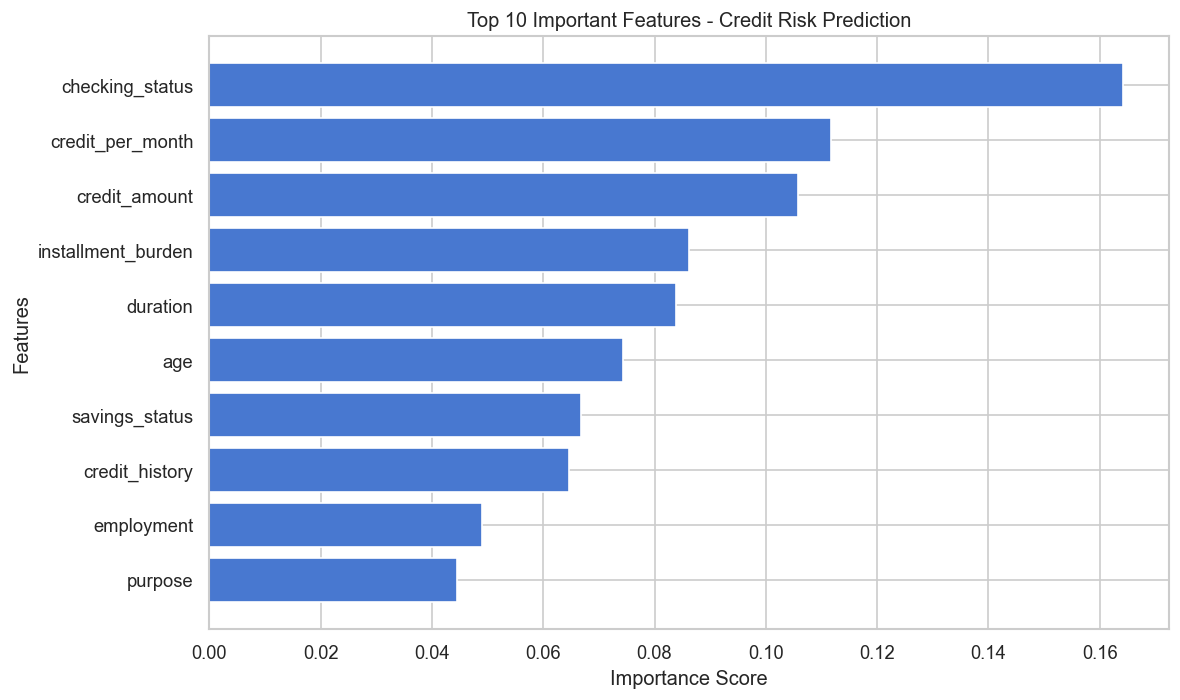

In [30]:


feature_importance = pd.DataFrame({
    'Feature': X_train_fe.columns,
    'Importance': best_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

# Display Top Features
print("Top Important Features")
display(feature_importance.head(10))

# Plot Feature Importance
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance['Feature'][:10][::-1],
    feature_importance['Importance'][:10][::-1]
)

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Top 10 Important Features - Credit Risk Prediction")

plt.tight_layout()
plt.show()

### Observation

The model heavily relies on financial behavior-related attributes such as checking status, credit amount, and loan duration while predicting applicant risk.

Features with higher importance contribute more significantly toward determining whether an applicant is classified as high risk or low risk.

### 9.3 - SHAP Explainability Analysis

In [31]:
# =========================================================
# SHAP Explainability
# =========================================================

# Create SHAP explainer
explainer = shap.TreeExplainer(best_model)

# Generate SHAP values
shap_values = explainer.shap_values(X_test_fe_sc)

print(" SHAP values generated successfully.")

 SHAP values generated successfully.


### 9.4 SHAP Summary Plot (Global Explainability)

In [36]:
print(model.classes_)

[0 1]


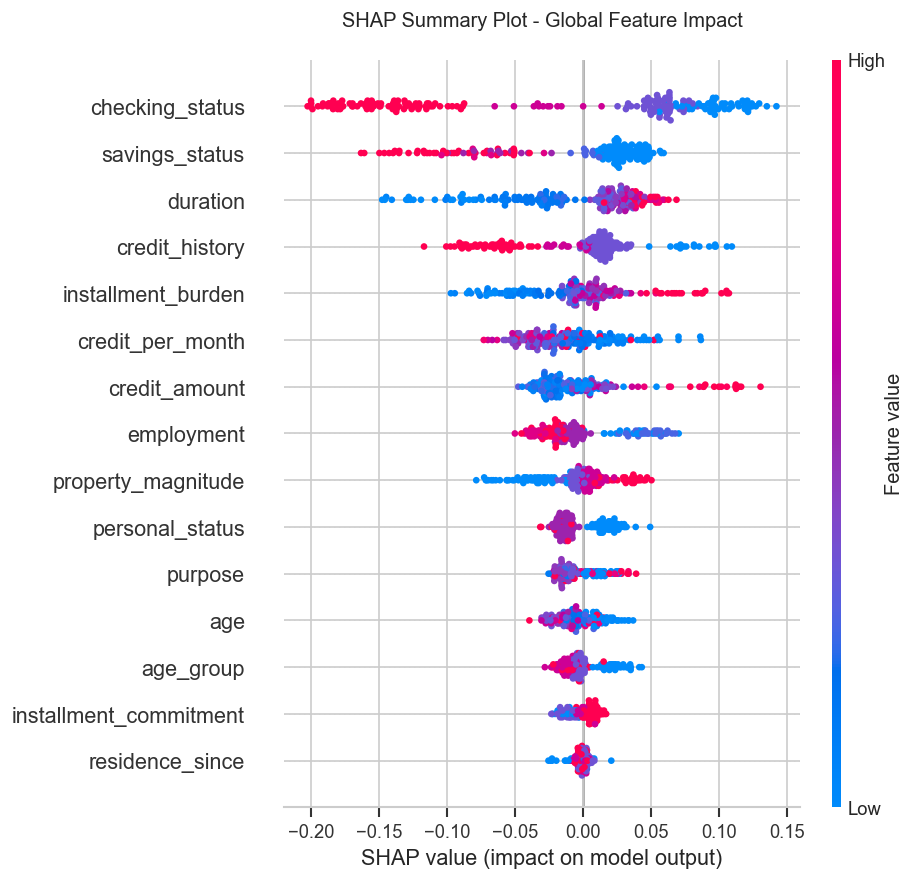

In [37]:
import shap
import matplotlib.pyplot as plt

shap.summary_plot(
    shap_values[:, :, 1],      # Positive class (class 1)
    X_test_fe_sc,
    feature_names=X_train_fe.columns,
    max_display=15,
    show=False
)

plt.title("SHAP Summary Plot - Global Feature Impact", pad=20)
plt.tight_layout()
plt.show()

Figure X shows the SHAP summary plot for the positive class (Class 1). Features are ranked by their average absolute SHAP values, indicating their overall contribution to the model's predictions. The feature checking_status has the highest impact, followed by savings_status, duration, and credit_history. Positive SHAP values increase the likelihood of predicting Class 1, while negative SHAP values decrease it.

### 9.5 SHAP Waterfall Plot (Local Explainability)

In [40]:
print(type(shap_values))
print(shap_values.shape)

<class 'numpy.ndarray'>
(200, 15, 2)


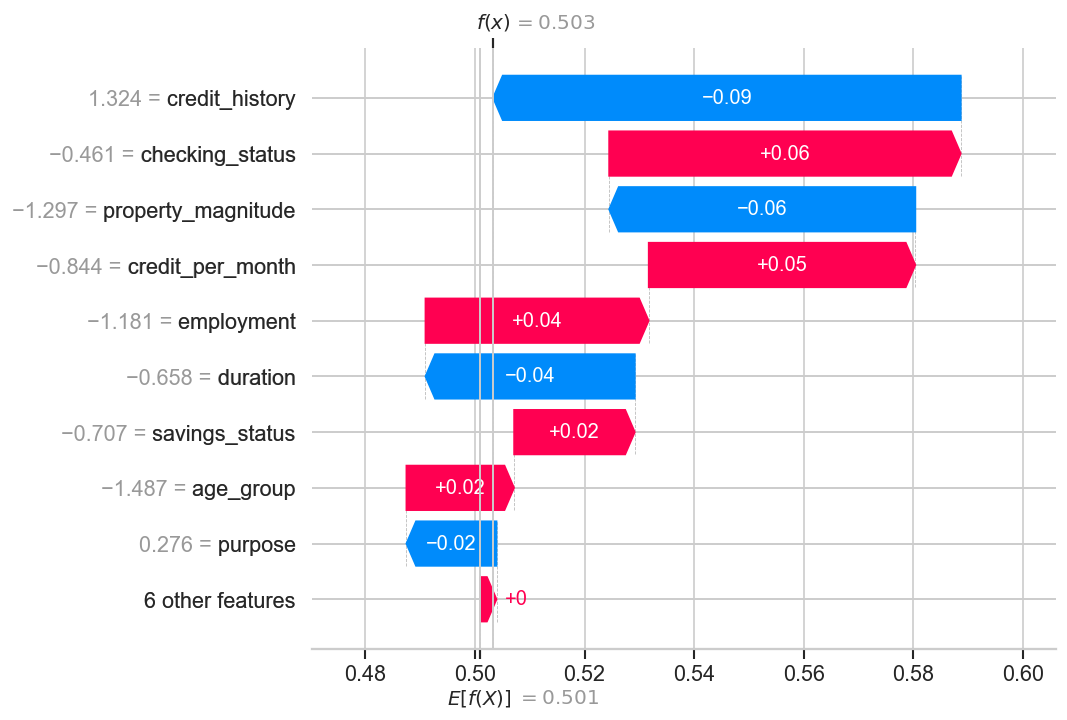

In [41]:
# =========================================================
# SHAP Waterfall Plot - Single Applicant
# =========================================================

sample_index = 5

exp = shap.Explanation(
    values=shap_values[sample_index, :, 1],   # Class 1
    base_values=explainer.expected_value[1],  # Class 1 base value
    data=X_test_fe_sc.iloc[sample_index],     # Row data
    feature_names=X_train_fe.columns
)

shap.plots.waterfall(exp)

### Local Explainability Interpretation

The waterfall plot explains why a specific applicant was predicted as high risk or low risk.

Each feature either:
- increases the predicted risk probability, or
- decreases the predicted risk probability.

For example:
- higher loan duration,
- lower checking account balance,
- larger credit amount

may contribute toward higher default risk.

This type of explanation is extremely useful in financial decision-making systems because it improves trust and interpretability.

### 9.6 Risk Probability Interpretation

In [43]:
# =========================================================
# Risk Probability Example
# =========================================================

sample_prediction = best_model.predict_proba(
    X_test_fe_sc.iloc[[sample_index]]
)[0]

print("Prediction Probabilities")
print(f"Low Risk Probability : {sample_prediction[0]:.4f}")
print(f"High Risk Probability: {sample_prediction[1]:.4f}")

Prediction Probabilities
Low Risk Probability : 0.4967
High Risk Probability: 0.5033


### Probability-Based Decision Support

Instead of generating only binary outputs, the model also provides probability scores.

This helps financial institutions:
- estimate uncertainty,
- prioritize manual review,
- make risk-aware lending decisions.

Probability-based systems are more practical than simple yes/no classification systems in real-world banking environments.

### 9.7 Business Interpretation of Explainability

# Business Interpretation of Explainability

Explainable AI plays an important role in financial systems where model transparency and fairness are critical.

The explainability analysis performed in this project helps:

- Understand why an applicant is classified as high risk or low risk
- Improve trust in automated decision-making systems
- Support financial analysts during loan approval processes
- Reduce black-box behavior in machine learning models
- Ensure better regulatory compliance and ethical AI practices

In banking and finance, prediction accuracy alone is not sufficient. Institutions also require interpretability to justify decisions and identify potential biases in the system.

By integrating SHAP-based explainability, this project improves both model transparency and practical usability.